## Annotation of Megkaryocyte subset

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib import rcParams

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3               
sc.logging.print_version_and_date()

# making sure plots & clusters are reproducible
np.random.seed(42)

# custom functions
import sc_toolbox as sct

Running Scanpy 1.8.2, on 2024-08-01 08:53.


In [2]:
## path variables
adata_path = '/mnt/smb2/Niklas/GLPG_data_temp/subsets/210211_megakaryocyte_subset_NIKLAS.h5ad'

In [3]:
## plotting variables
sc.settings.figdir = '/home/agando/Documents/Niklas/Projects/niche_environments_FIBROSIS/GLPG_full_bleomycin_10X_MICE/Figures/megakaryocyte_subset'
sc.set_figure_params(vector_friendly = True)
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['pdf.fonttype'] = 42

In [4]:
## load anndata object
adata = sc.read(adata_path)

In [5]:
## have a look at the adata object
adata

AnnData object with n_obs × n_vars = 543 × 25194
    obs: 'identifier', 'time_point', 'n_counts', 'preprocessing_cluster', 'size_factors', 'S_score', 'G2M_score', 'phase', 'treatment_time', 'treatment', 'sample_name', 'condition', 'percent_mito', 'cluster_03', 'GLPG_annotation', 'doublet_scores', 'n_genes', 'louvain_1', 'louvain_2'
    var: 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'GLPG_annotation_colors', 'cluster_03_colors', 'condition_colors', 'hvg', 'identifier_colors', 'louvain', 'louvain_1_colors', 'neighbors', 'pca', 'time_point_colors', 'treatment_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'unsouped_counts'
    obsp: 'connectivities', 'distances'

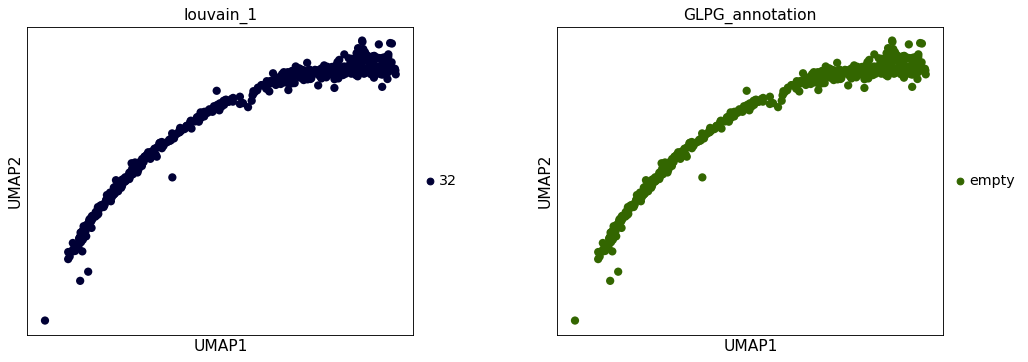

In [6]:
## overview plot
sc.pl.umap(adata, color = ['louvain_1', 'GLPG_annotation'], wspace = .25)

### Remove outliers with DBscan

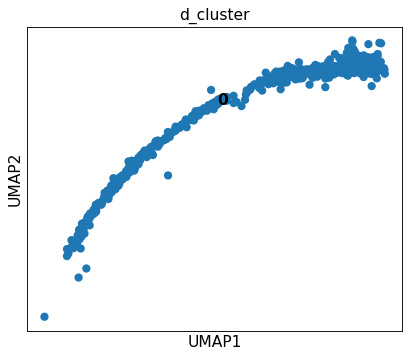

In [7]:
## using Herbert's old code snippet here
from natsort import natsorted
from sklearn.cluster import DBSCAN
def cluster_by_dscan(cords, eps, min_samples):
    clustering = DBSCAN(eps = eps, min_samples = min_samples).fit(cords)
    return clustering.labels_

adata.obs['d_cluster'] = cluster_by_dscan(adata.obsm['X_umap'], eps = 0.5, min_samples = 5)
c = adata.obs['d_cluster'].astype("U")
adata.obs['d_cluster'] = pd.Categorical(c, categories = natsorted(np.unique(c)))

sc.pl.umap(adata, color = 'd_cluster', legend_loc='on data')

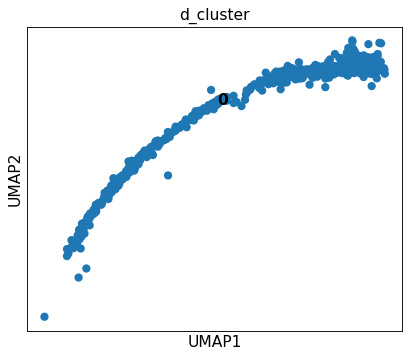

In [8]:
## discard outliers
adata = adata[adata.obs['d_cluster'].isin(['0','1'])].copy()
sc.pl.umap(adata, color = 'd_cluster', legend_loc='on data')

### Calculate HVGs

In [9]:
sc.pp.highly_variable_genes(adata, n_top_genes = 1000, flavor = 'seurat')

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


### PCA

computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


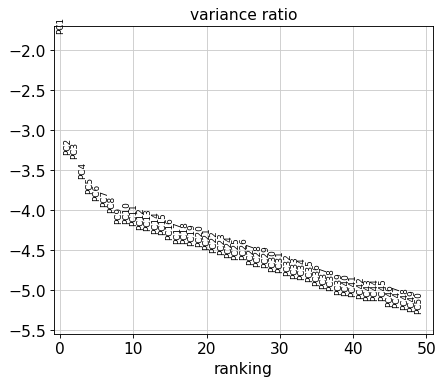

In [10]:
## PCA
sc.pp.pca(adata, use_highly_variable = True)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

### kNN graph

In [11]:
sc.pp.neighbors(adata, n_pcs = 50, n_neighbors = 30) # without batch correction

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


### Graph-based clustering and Visualization

running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 2 clusters and added
    'sub_louvain', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:01)


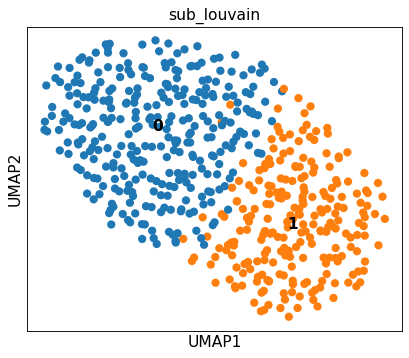

In [12]:
sc.tl.louvain(adata, resolution = 0.5, key_added = 'sub_louvain')
sc.tl.umap(adata)
sc.pl.umap(adata, color = ['sub_louvain'], legend_loc = 'on data')

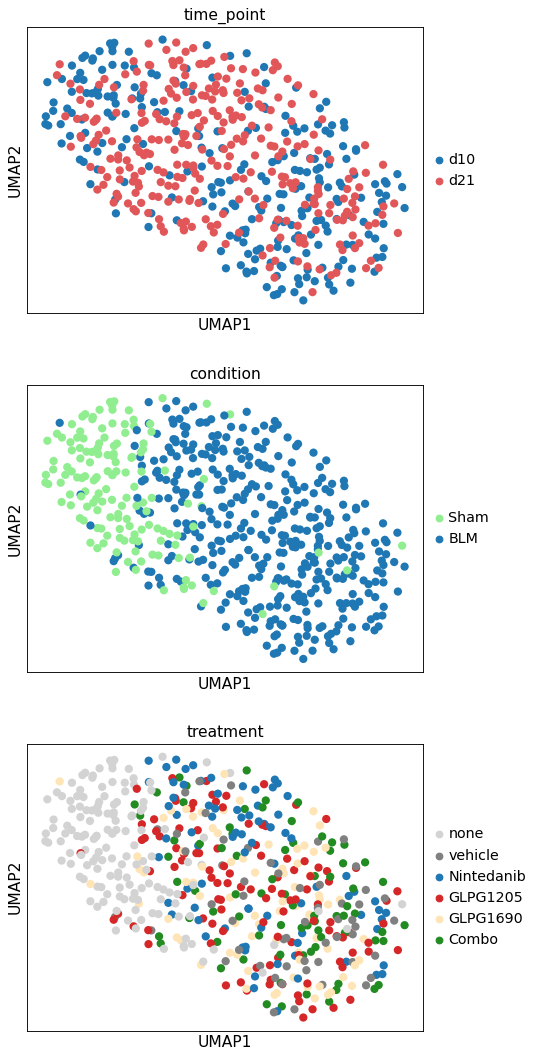

In [13]:
sc.pl.umap(adata, color = ['time_point', 'condition', 'treatment'], ncols = 1)

### Plot QC metrics

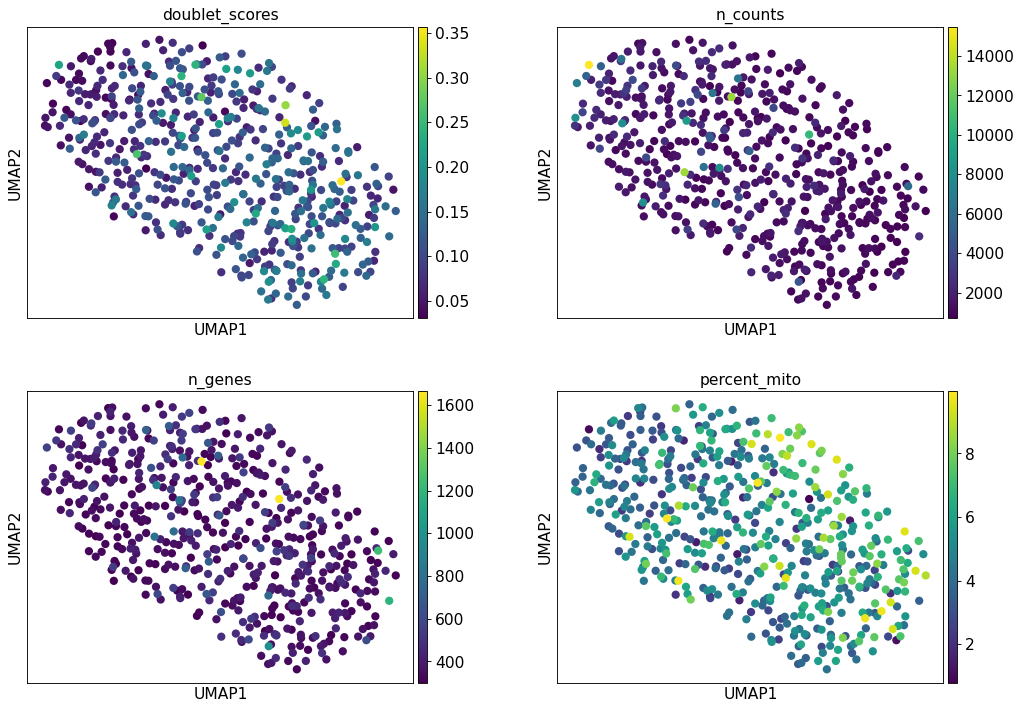

In [14]:
sc.pl.umap(adata, color = ['doublet_scores', 'n_counts', 'n_genes', 'percent_mito'], ncols = 2, wspace = 0.25)

### Plot marker genes

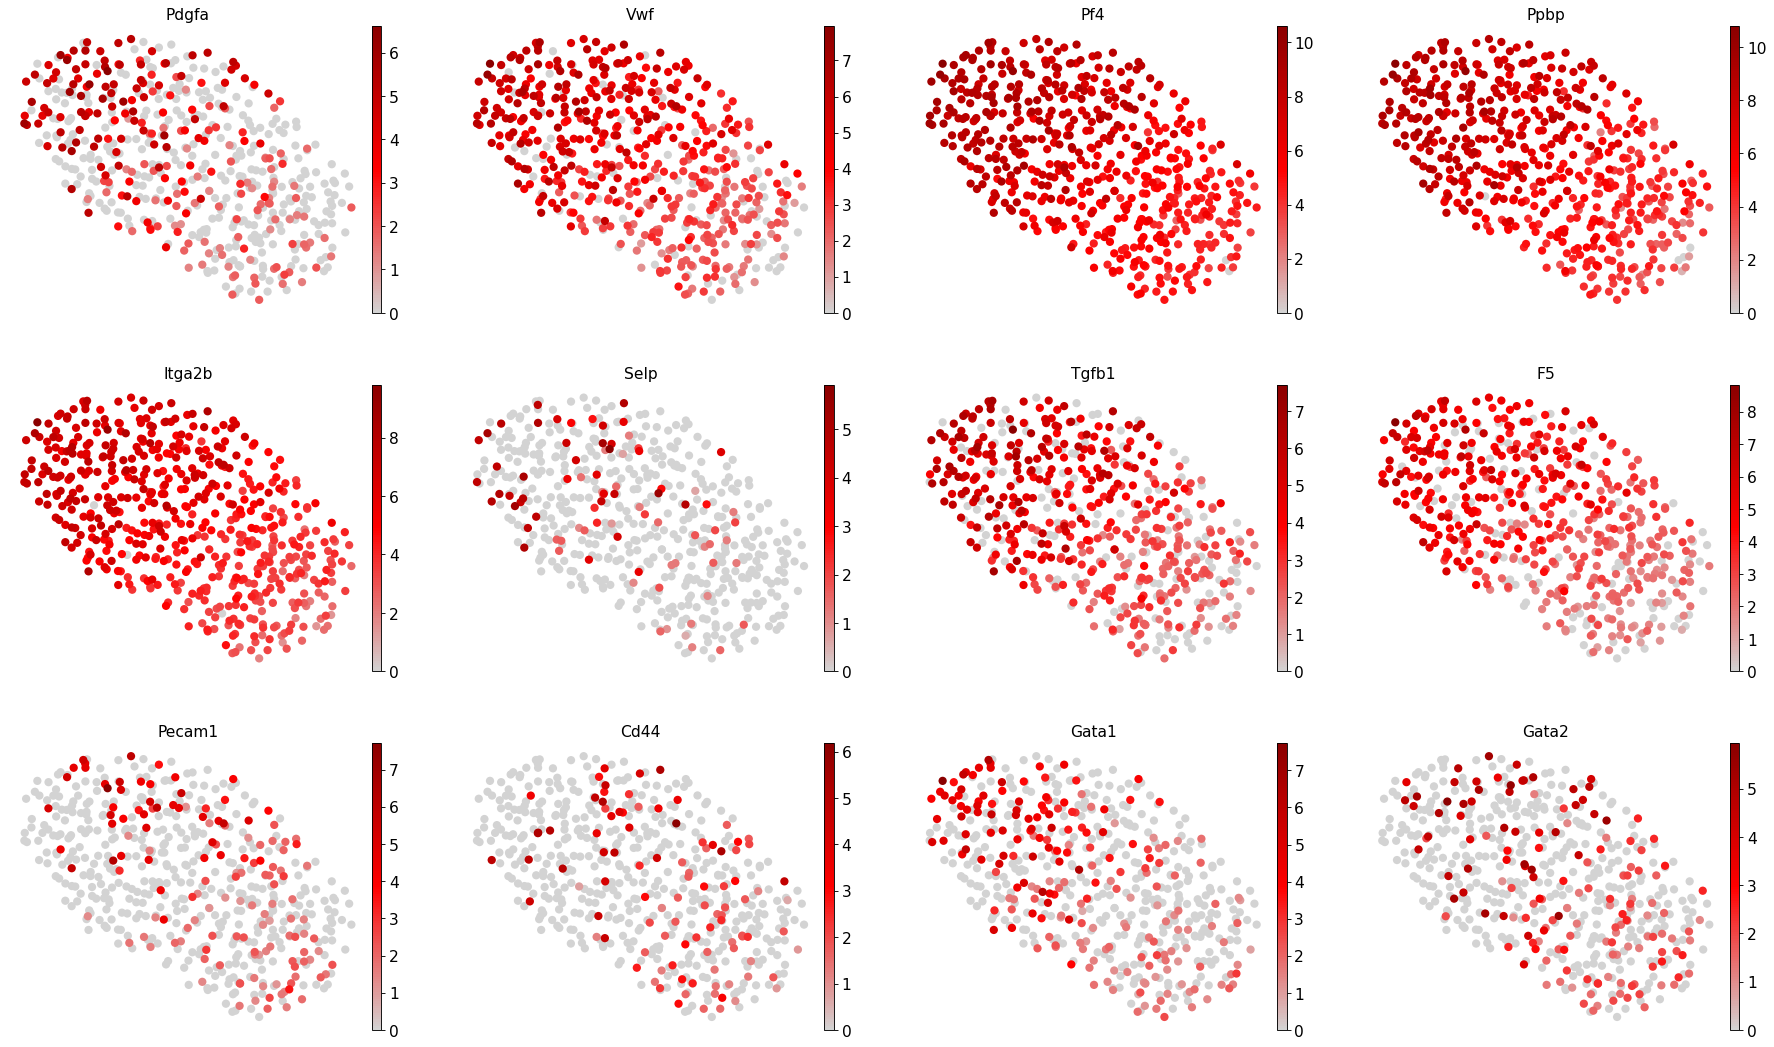

In [15]:
sc.pl.umap(adata, color = ['Pdgfa', 'Vwf', 'Pf4', 'Ppbp', 'Itga2b', 
                           'Selp', 'Tgfb1', 'F5', 'Pecam1', 'Cd44',
                           'Gata1', 'Gata2'],ncols = 4,
           cmap = gray_red, frameon = False)     

### Cluster Annotation

... storing 'cell_type' as categorical


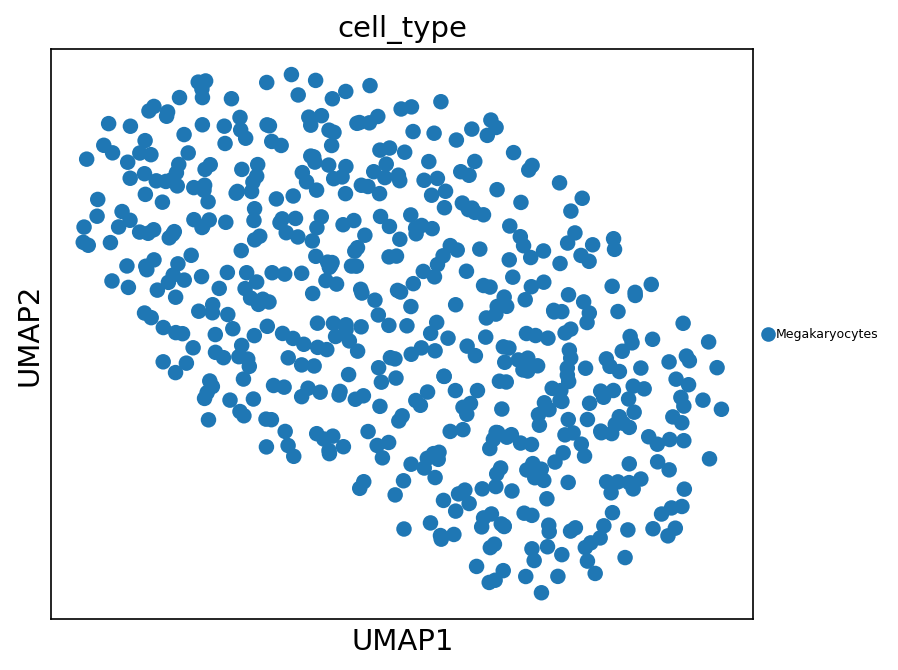

In [16]:
cell_type = {'0' : 'Megakaryocytes',
             '1' : 'Megakaryocytes'}
adata.obs['cell_type'] = [cell_type[cluster] for cluster in adata.obs['sub_louvain']]
sc.pl.umap(adata, color = 'cell_type', ax = mysize(6, 5, 150), legend_fontsize = 6)

### Summary figures

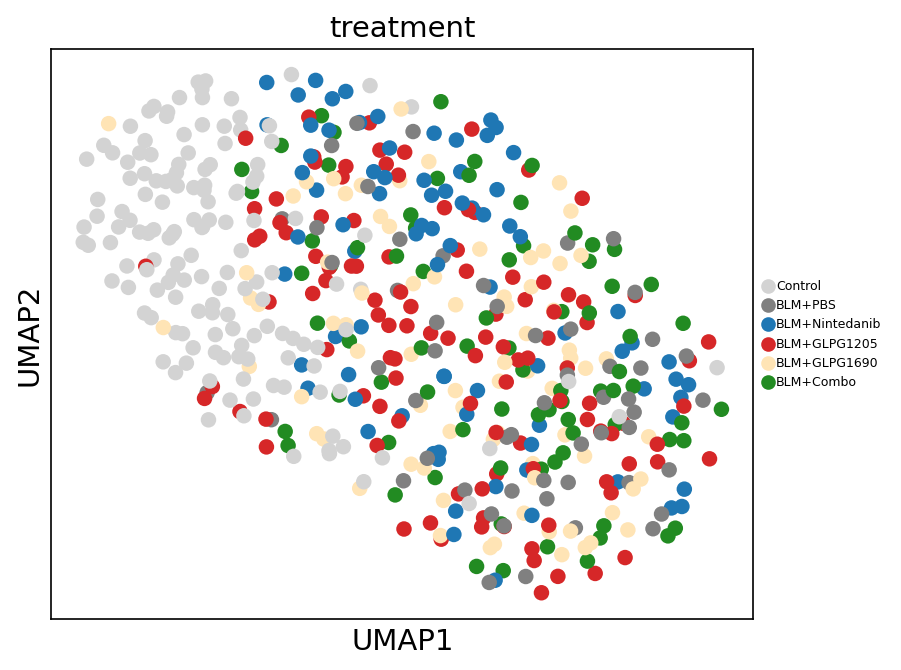

In [17]:
# rename condition label upon request of GLPG :)
treatment_conversion = {'none' : 'Control',
                        'vehicle' : 'BLM+PBS',
                        'Nintedanib' : 'BLM+Nintedanib',
                        'GLPG1205' : 'BLM+GLPG1205',
                        'GLPG1690' : 'BLM+GLPG1690',
                        'Combo' : 'BLM+Combo'
}
adata.obs['treatment'] = [treatment_conversion[t] for t in adata.obs['treatment']]
## reorder condition labels
adata.obs['treatment'] = adata.obs['treatment'].astype('category')
adata.obs['treatment'] = adata.obs['treatment'].cat.reorder_categories(['Control','BLM+PBS',
                                                                        'BLM+Nintedanib',
                                                                        'BLM+GLPG1205',
                                                                        'BLM+GLPG1690',
                                                                        'BLM+Combo'])
## plot UMAPs with new labels
sc.pl.umap(adata, color = 'treatment', ax = mysize(6, 5, 150), legend_fontsize = 6)

... storing 'treatment_time' as categorical


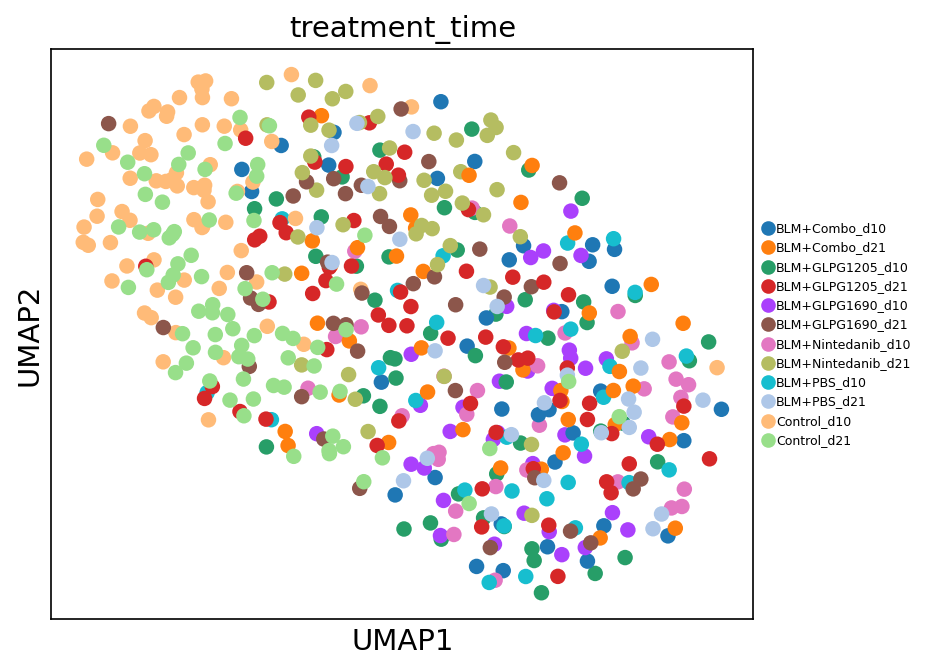

In [18]:
## rename treatment_time label upon request of GLPG :)
treatment_time_conversion = {'none_d10' : 'Control_d10',
                             'none_d21' : 'Control_d21',
                             'vehicle_d10' : 'BLM+PBS_d10',
                             'vehicle_d21' : 'BLM+PBS_d21',
                             'Nintedanib_d10' : 'BLM+Nintedanib_d10',
                             'Nintedanib_d21' : 'BLM+Nintedanib_d21',
                             'GLPG1205_d10' : 'BLM+GLPG1205_d10',
                             'GLPG1205_d21' : 'BLM+GLPG1205_d21',
                             'GLPG1690_d10' : 'BLM+GLPG1690_d10',
                             'GLPG1690_d21' : 'BLM+GLPG1690_d21',
                             'Combo_d10' : 'BLM+Combo_d10',
                             'Combo_d21' : 'BLM+Combo_d21'
}
adata.obs['treatment_time'] = [treatment_time_conversion[tt] for tt in adata.obs['treatment_time']]
sc.pl.umap(adata, color = 'treatment_time', ax = mysize(6, 5, 150), legend_fontsize = 6)

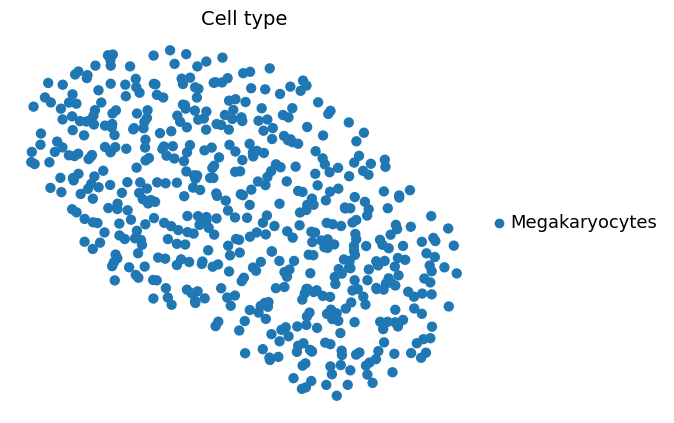

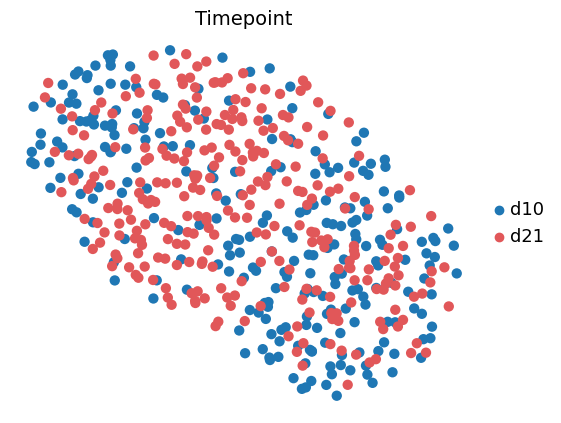

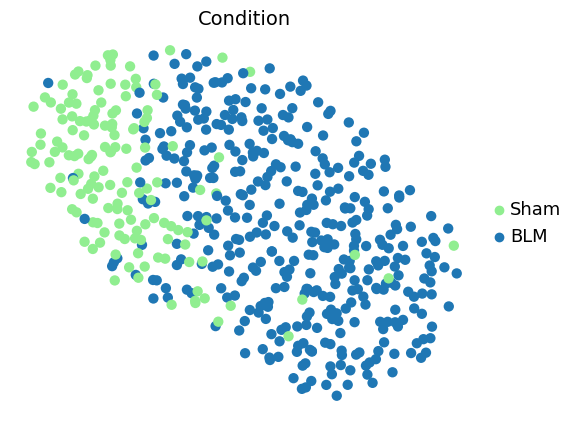

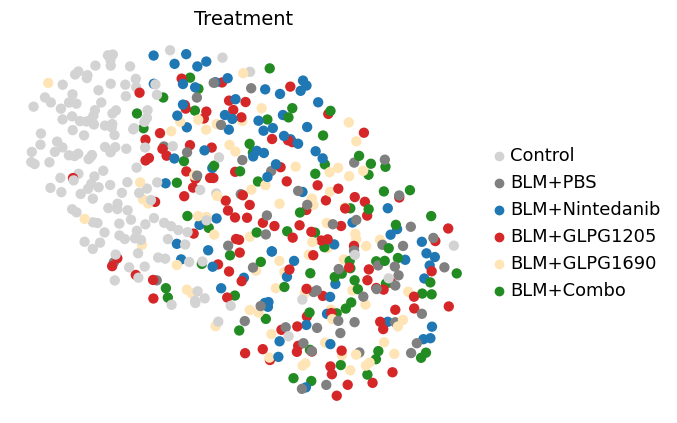

In [19]:
## save UMAP of MNPs for future use
sc.pl.umap(adata, color = ['cell_type'], title = 'Cell type', frameon = False, 
           ax = mysize(6, 5, 100),  save = '_celltype.pdf')
sc.pl.umap(adata, color = ['time_point'], title = 'Timepoint', frameon = False, 
           ax = mysize(6, 5, 100), save = '_timepoint.pdf')
sc.pl.umap(adata, color = ['condition'], title = 'Condition', frameon = False, 
           ax = mysize(6, 5, 100), save = '_condition.pdf')
sc.pl.umap(adata, color = ['treatment'], title = 'Treatment', frameon = False, 
           ax = mysize(6, 5, 100), save = '_treatment.pdf')

### Save annotated subset

In [20]:
## save adata object
adata.write('/mnt/platte_1/Projects/210115_GLPG/subsets/210218_megakaryocyte_subset_NIKLAS_annotated.h5ad')